In [17]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent
FLOW_DIR = PROJECT_DIR / "z.flow_postprocessing"
FLOW_SCRIPTS_DIR = FLOW_DIR / "scripts"

for path in [PROJECT_DIR, FLOW_SCRIPTS_DIR]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)

import theme.plot_theme as ptheme
import shcherbina_utils as shu

importlib.reload(ptheme)
ptheme.apply_theme()
importlib.reload(shu)
shu.apply_plot_style()

print(f"Notebook dir     : {NB_DIR}")
print(f"Project dir      : {PROJECT_DIR}")
print(f"Flow scripts dir : {FLOW_SCRIPTS_DIR}")



Notebook dir     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\notebooks
Project dir      : C:\Users\Jelle Gortemaker\Documents\Thesis
Flow scripts dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.flow_postprocessing\scripts


C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap_r' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\Users\Jelle Gortemaker\Documents\Thesis\theme\plot_theme.py:110: UserWarning: Overwriting the cmap 'toc_cmap' that was already in the registry.
  mpl.colormaps.register(cmap, name=name, force=True)
C:\

In [25]:
case_name = "parcels_sea_win_spinupsim_L1"                 # edit
RUN_TITLE_INFO = "parcels_sea_win_spinupsim_L1"             # edit

DATA_FILE = (NB_DIR / f"../data/input/{case_name}.nc").resolve()
ds = xr.open_dataset(DATA_FILE, chunks="auto")


In [34]:
# ============================================================
# SETTINGS
# ============================================================

case_files = {
    "no rbcs": "../data/input/parcels_sea_win_spinupsim_L1.nc",
    "rbcs": "../data/input/run_rbcs7.nc",
}

U_NAME = "UVEL"
V_NAME = "VVEL"
TIME_DIM = "T"
Z_INDEX = 0

SPECTRUM_VAR = "shell_integrated_spectrum"
# or:
# SPECTRUM_VAR = "spectral_density"

Processing case: no rbcs
File: ../data/input/parcels_sea_win_spinupsim_L1.nc
{'dt_seconds': 10800.0, 'dt_hours': 3.0, 'nt': 224, 'duration_days': 28.0, 'ny_used': 512, 'nx_used': 512, 'remove_mean': True, 'detrend_linear': False, 'method': 'temporal_fft_velocity_then_spatial_power_average', 'normalization': '0.5*(|u_hat|^2+|v_hat|^2)/nt^2, spatially averaged'}
Processing case: rbcs
File: ../data/input/run_rbcs7.nc
{'dt_seconds': 5400.0, 'dt_hours': 1.5, 'nt': 80, 'duration_days': 5.0, 'ny_used': 512, 'nx_used': 512, 'remove_mean': True, 'detrend_linear': False, 'method': 'temporal_fft_velocity_then_spatial_power_average', 'normalization': '0.5*(|u_hat|^2+|v_hat|^2)/nt^2, spatially averaged'}


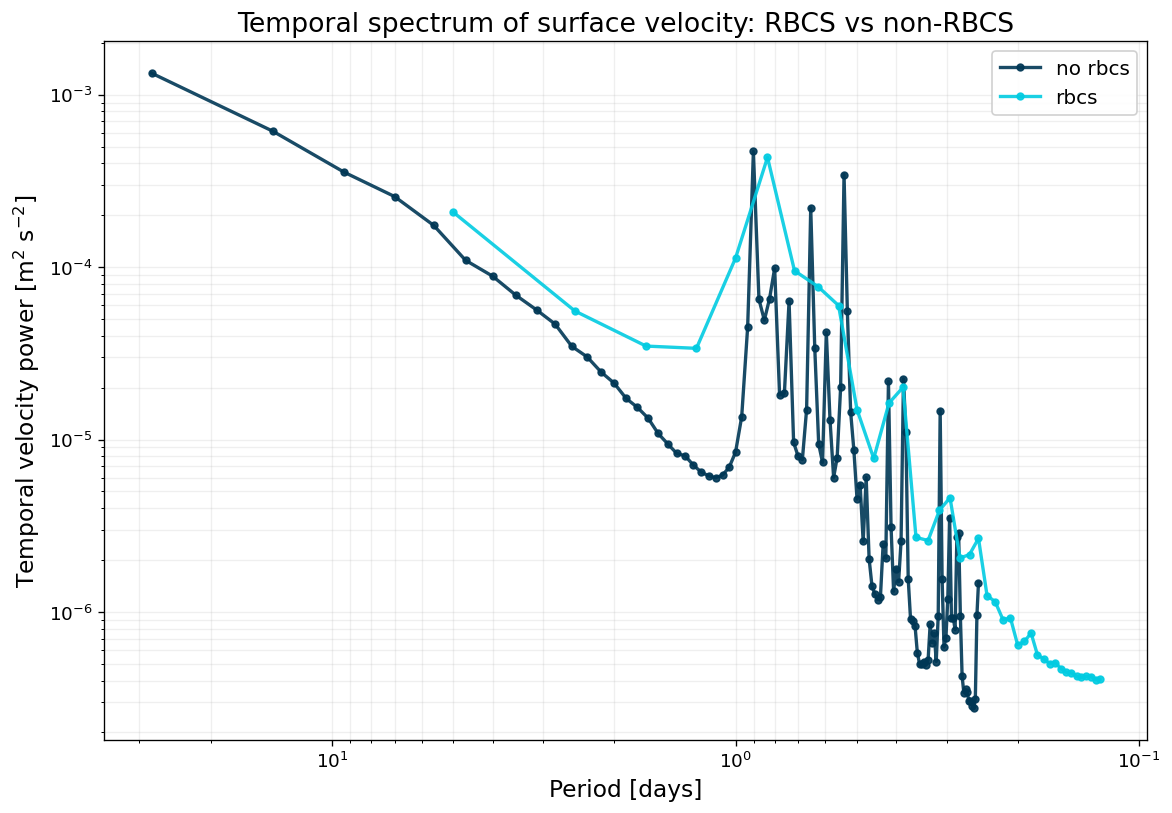

In [35]:
# ============================================================
# COMPUTE FULL-RUN TEMPORAL SPECTRA
# ============================================================

spectra_full = {}

for case_name, path in case_files.items():
    print(f"Processing case: {case_name}")
    print(f"File: {path}")

    ds_case = xr.open_dataset(path)

    spectra_full[case_name] = calculate_temporal_velocity_spectrum(
        ds_case,
        u_name=U_NAME,
        v_name=V_NAME,
        time_dim=TIME_DIM,
        z_index=Z_INDEX,
        remove_mean=True,
        detrend_linear=False,
    )

    print(spectra_full[case_name].attrs)
    ds_case.close()

def plot_temporal_velocity_spectrum_comparison(
    spectra_dict,
    spectrum_var="shell_integrated_spectrum",
    title="Temporal spectrum of surface velocity",
    xlim_days=None,
    ylim=None,
    save_path=None,
    save=False,
):
    """
    Compare temporal velocity spectra using the same simple style as the EDS plots.
    """

    ylabel_map = {
        "shell_integrated_spectrum": r"Temporal velocity power [m$^2$ s$^{-2}$]",
        "spectral_density": r"Temporal spectral density [(m$^2$ s$^{-2}$)/(cycles s$^{-1}$)]",
    }

    if spectrum_var not in ylabel_map:
        raise ValueError(
            "spectrum_var must be 'shell_integrated_spectrum' or 'spectral_density'"
        )

    plt.figure(figsize=(10, 7))

    for case_name, spec in spectra_dict.items():
        period_days = spec["period_days"].values
        E = spec[spectrum_var].values

        valid = (
            np.isfinite(period_days)
            & np.isfinite(E)
            & (period_days > 0.0)
            & (E > 0.0)
        )

        plt.loglog(
            period_days[valid],
            E[valid],
            marker="o",
            markersize=4,
            linewidth=2,
            alpha=0.9,
            label=case_name,
        )

    plt.gca().invert_xaxis()
    plt.xlabel("Period [days]")
    plt.ylabel(ylabel_map[spectrum_var])
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", alpha=0.2)

    if xlim_days is not None:
        plt.xlim(xlim_days)

    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()

    if save and save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")

    plt.show()

plot_temporal_velocity_spectrum_comparison(
    spectra_full,
    spectrum_var=SPECTRUM_VAR,
    title="Temporal spectrum of surface velocity: RBCS vs non-RBCS",
)

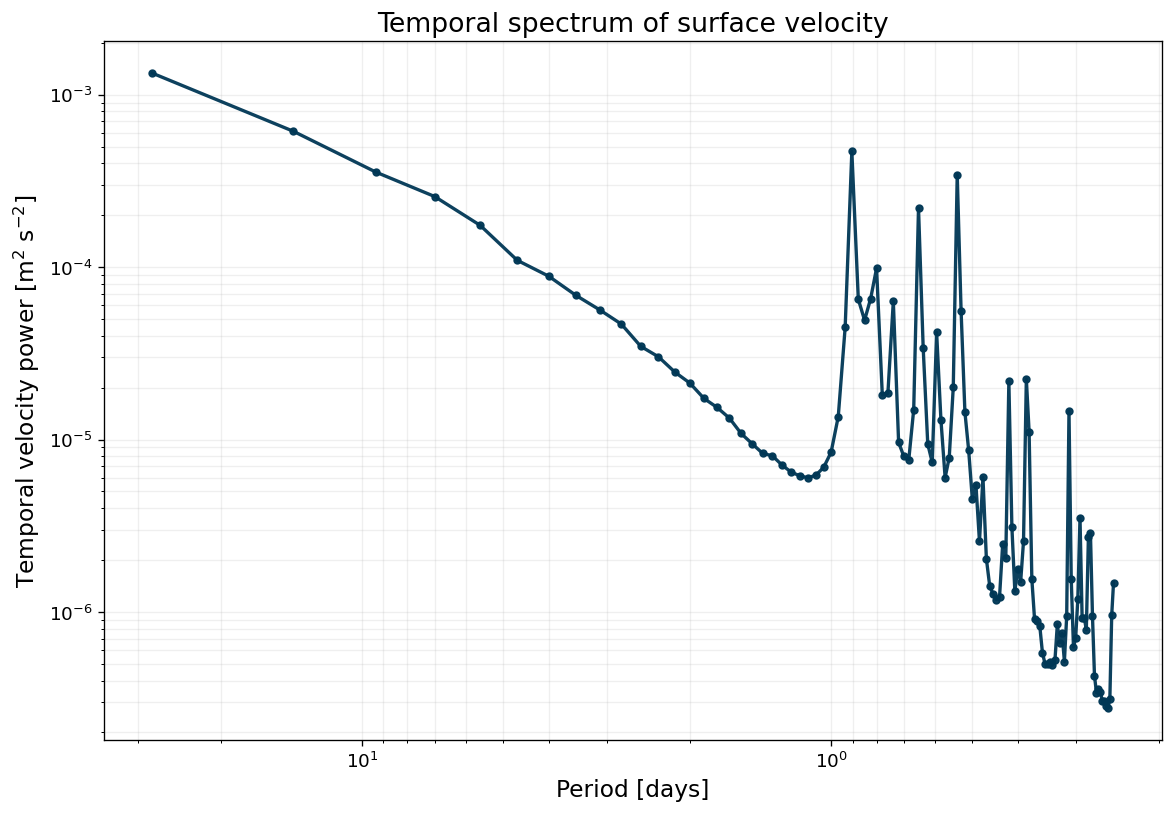

In [23]:
def calculate_temporal_velocity_spectrum(
    ds,
    u_name="UVEL",
    v_name="VVEL",
    time_dim="T",
    z_index=0,
    remove_mean=True,
    detrend_linear=False,
):
    """
    Calculate a temporal velocity spectrum from MITgcm UVEL/VVEL.

    Method follows the same logic as calculate_EDS, but with FFT in time:

    - select one vertical layer
    - crop UVEL/VVEL to common C-grid size
    - remove temporal mean at each grid point
    - compute FFT in time at each grid point
    - form velocity-power spectrum from UVEL and VVEL
    - average over horizontal grid points

    No temporal window is applied.

    Returns
    -------
    xr.Dataset with:
        shell_integrated_spectrum(frequency)
        spectral_density(frequency)
        period_days(frequency)
    """

    u = ds[u_name]
    v = ds[v_name]

    if time_dim not in u.dims:
        raise ValueError(f"{time_dim=} not found in {u_name} dims: {u.dims}")
    if time_dim not in v.dims:
        raise ValueError(f"{time_dim=} not found in {v_name} dims: {v.dims}")

    # Put time first
    u = u.transpose(time_dim, ...)
    v = v.transpose(time_dim, ...)

    u_arr = u.values.astype(float)
    v_arr = v.values.astype(float)

    # MITgcm/MNC often gives (time, z, y, x)
    if u_arr.ndim == 4:
        u_arr = u_arr[:, z_index, :, :]
    if v_arr.ndim == 4:
        v_arr = v_arr[:, z_index, :, :]

    if u_arr.ndim != 3 or v_arr.ndim != 3:
        raise ValueError(
            "Expected UVEL and VVEL to be 3D after vertical selection: "
            f"(time, y, x). Got {u_name}: {u_arr.shape}, {v_name}: {v_arr.shape}."
        )

    # Crop staggered C-grid fields to common size
    nt_u, ny_u, nx_u = u_arr.shape
    nt_v, ny_v, nx_v = v_arr.shape

    if nt_u != nt_v:
        raise ValueError(f"Different time lengths: {nt_u} and {nt_v}")

    nt = nt_u
    ny = min(ny_u, ny_v)
    nx = min(nx_u, nx_v)

    u_arr = u_arr[:, :ny, :nx]
    v_arr = v_arr[:, :ny, :nx]

    # Infer time step
    t = u[time_dim].values

    if len(t) < 2:
        raise ValueError("Need at least two time steps for temporal FFT.")

    if np.issubdtype(np.asarray(t).dtype, np.datetime64):
        dt_seconds = float((t[1] - t[0]) / np.timedelta64(1, "s"))
    else:
        dt_seconds = float(np.nanmedian(np.diff(t)))

    if not np.isfinite(dt_seconds) or dt_seconds <= 0:
        raise ValueError(f"Invalid dt_seconds: {dt_seconds}")

    # Replace NaNs
    u_arr = np.nan_to_num(u_arr, nan=0.0)
    v_arr = np.nan_to_num(v_arr, nan=0.0)

    # Remove temporal mean at each grid point
    if remove_mean:
        u_arr = u_arr - np.mean(u_arr, axis=0, keepdims=True)
        v_arr = v_arr - np.mean(v_arr, axis=0, keepdims=True)

    # Optional linear detrend, off by default to stay close to EDS logic
    if detrend_linear:
        tt = np.arange(nt, dtype=float)
        tt = tt - tt.mean()
        tt3 = tt[:, None, None]
        denom = np.sum(tt**2)

        u_slope = np.sum(u_arr * tt3, axis=0, keepdims=True) / denom
        v_slope = np.sum(v_arr * tt3, axis=0, keepdims=True) / denom

        u_arr = u_arr - u_slope * tt3
        v_arr = v_arr - v_slope * tt3

    # Temporal FFT
    u_hat = np.fft.rfft(u_arr, axis=0)
    v_hat = np.fft.rfft(v_arr, axis=0)

    frequency = np.fft.rfftfreq(nt, d=dt_seconds)

    # Same normalization idea as spatial EDS:
    # spatial EDS: 0.5*(|u_hat|^2+|v_hat|^2)/(nx*ny)^2
    # temporal version: 0.5*(|u_hat|^2+|v_hat|^2)/nt^2
    power_3d = 0.5 * (np.abs(u_hat)**2 + np.abs(v_hat)**2) / (nt**2)

    shell_integrated = np.nanmean(power_3d, axis=(1, 2))

    df = frequency[1] - frequency[0] if len(frequency) > 1 else np.nan
    spectral_density = shell_integrated / df

    period_days = np.full_like(frequency, np.nan, dtype=float)
    valid = frequency > 0.0
    period_days[valid] = 1.0 / frequency[valid] / 86400.0

    # Respect Nyquist and remove zero-frequency mode from returned result
    keep = frequency > 0.0

    return xr.Dataset(
        data_vars={
            "shell_integrated_spectrum": (
                ("frequency",),
                shell_integrated[keep],
            ),
            "spectral_density": (
                ("frequency",),
                spectral_density[keep],
            ),
            "period_days": (
                ("frequency",),
                period_days[keep],
            ),
        },
        coords={
            "frequency": frequency[keep],
        },
        attrs={
            "dt_seconds": float(dt_seconds),
            "dt_hours": float(dt_seconds / 3600.0),
            "nt": int(nt),
            "duration_days": float(nt * dt_seconds / 86400.0),
            "ny_used": int(ny),
            "nx_used": int(nx),
            "remove_mean": bool(remove_mean),
            "detrend_linear": bool(detrend_linear),
            "method": "temporal_fft_velocity_then_spatial_power_average",
            "normalization": "0.5*(|u_hat|^2+|v_hat|^2)/nt^2, spatially averaged",
        },
    )


def plot_temporal_velocity_spectrum(
    spec,
    spectrum_var="shell_integrated_spectrum",
    title="Temporal spectrum of surface velocity",
    xlim_days=None,
    ylim=None,
    save_path=None,
    save=False,
):
    """
    Plot temporal velocity spectrum using the same simple style as the EDS plots.
    """

    ylabel_map = {
        "shell_integrated_spectrum": r"Temporal velocity power [m$^2$ s$^{-2}$]",
        "spectral_density": r"Temporal spectral density [(m$^2$ s$^{-2}$)/(cycles s$^{-1}$)]",
    }

    if spectrum_var not in ylabel_map:
        raise ValueError(
            "spectrum_var must be 'shell_integrated_spectrum' or 'spectral_density'"
        )

    period_days = spec["period_days"].values
    E = spec[spectrum_var].values

    valid = (
        np.isfinite(period_days)
        & np.isfinite(E)
        & (period_days > 0.0)
        & (E > 0.0)
    )

    fig, ax = plt.subplots(figsize=(10, 7), facecolor="white")
    ax.set_facecolor("white")

    ax.loglog(
        period_days[valid],
        E[valid],
        marker="o",
        markersize=4,
        linewidth=2,
        color="#003755",
        alpha=0.95,
    )

    ax.invert_xaxis()

    ax.set_xlabel("Period [days]")
    ax.set_ylabel(ylabel_map[spectrum_var])
    ax.set_title(title)

    ax.grid(True, which="both", alpha=0.2)

    if xlim_days is not None:
        ax.set_xlim(xlim_days)

    if ylim is not None:
        ax.set_ylim(ylim)

    fig.tight_layout()

    if save and save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax

def plot_temporal_velocity_spectrum_comparison(
    spectra,
    labels,
    spectrum_var="shell_integrated_spectrum",
    title="Temporal spectrum of surface velocity",
    xlim_days=None,
    ylim=None,
    save_path=None,
    save=False,
):
    """
    Compare temporal velocity spectra using the same simple EDS plot style.
    """

    ylabel_map = {
        "shell_integrated_spectrum": r"Temporal velocity power [m$^2$ s$^{-2}$]",
        "spectral_density": r"Temporal spectral density [(m$^2$ s$^{-2}$)/(cycles s$^{-1}$)]",
    }

    if spectrum_var not in ylabel_map:
        raise ValueError(
            "spectrum_var must be 'shell_integrated_spectrum' or 'spectral_density'"
        )

    fig, ax = plt.subplots(figsize=(10, 7), facecolor="white")
    ax.set_facecolor("white")

    for spec, label in zip(spectra, labels):
        period_days = spec["period_days"].values
        E = spec[spectrum_var].values

        valid = (
            np.isfinite(period_days)
            & np.isfinite(E)
            & (period_days > 0.0)
            & (E > 0.0)
        )

        ax.loglog(
            period_days[valid],
            E[valid],
            marker="o",
            markersize=4,
            linewidth=2,
            alpha=0.9,
            label=label,
        )

    ax.invert_xaxis()

    ax.set_xlabel("Period [days]")
    ax.set_ylabel(ylabel_map[spectrum_var])
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which="both", alpha=0.2)

    if xlim_days is not None:
        ax.set_xlim(xlim_days)

    if ylim is not None:
        ax.set_ylim(ylim)

    fig.tight_layout()

    if save and save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")

    plt.show()

    return fig, ax

spec_full = calculate_temporal_velocity_spectrum(
    ds,
    u_name="UVEL",
    v_name="VVEL",
    time_dim="T",
    z_index=0,
    remove_mean=True,
    detrend_linear=False,
)

fig, ax = plot_temporal_velocity_spectrum(
    spec_full,
    spectrum_var="shell_integrated_spectrum",
    title="Temporal spectrum of surface velocity",
)

